In [1]:
import pandas as pd

# Load model outputs
df_gemini = pd.read_csv("test_items_set/model_outputs/gemini_gemini-2.5-flash.csv")
df_41 = pd.read_csv("test_items_set/model_outputs/openai_gpt-4.1.csv")
df_4o = pd.read_csv("test_items_set/model_outputs/openai_gpt-4o.csv")
df_mini = pd.read_csv("test_items_set/model_outputs/openai_gpt-4o-mini.csv")

# Load ground truth
df_gt = pd.read_csv("test_items_set/test_items_enriched.csv")

print("Loaded datasets")

Loaded datasets


In [5]:
def parse_tags(x):
    if pd.isna(x) or x == "":
        return set()
    return set(str(x).split(";"))

In [2]:
def tag_f1(gt, pred):
    gt, pred = set(gt), set(pred)

    if len(gt) == 0 and len(pred) == 0:
        return 1.0

    inter = len(gt & pred)
    precision = inter / len(pred) if pred else 0
    recall = inter / len(gt) if gt else 0

    if precision + recall == 0:
        return 0

    return 2 * precision * recall / (precision + recall)

In [3]:
TAG_FIELDS = ["themes", "occasions", "vibes", "styles", "aesthetic", "fit", "season", "function"]

def evaluate_model(df_pred, df_gt):
    df = df_pred.merge(df_gt, on="id", suffixes=("_pred", "_gt"))

    results = {}

    # --- Subcategory accuracy ---
    results["subcat1_acc"] = (df["subCategory_1_pred"] == df["subCategory_1_gt"]).mean()
    results["subcat2_acc"] = (df["subCategory_2_pred"] == df["subCategory_2_gt"]).mean()

    # --- Tag F1 ---
    tag_scores = []

    for field in TAG_FIELDS:
        scores = []
        for _, row in df.iterrows():
            gt = parse_tags(row[f"{field}_gt"])
            pred = parse_tags(row[f"{field}_pred"])
            scores.append(tag_f1(gt, pred))

        results[f"{field}_f1"] = sum(scores) / len(scores)
        tag_scores.append(results[f"{field}_f1"])

    results["tag_f1_avg"] = sum(tag_scores) / len(tag_scores)

    return results

In [6]:
results = {
    "gpt-4o": evaluate_model(df_4o, df_gt),
    "gpt-4o-mini": evaluate_model(df_mini, df_gt),
    "gpt-4.1": evaluate_model(df_41, df_gt),
    "gemini": evaluate_model(df_gemini, df_gt),
}

df_results = pd.DataFrame(results).T
df_results

,subcat1_acc,subcat2_acc,themes_f1,occasions_f1,vibes_f1,styles_f1,aesthetic_f1,fit_f1,season_f1,function_f1,tag_f1_avg
gpt-4o,0.800000,0.700000,0.641667,0.616667,0.503333,0.646667,0.350000,0.708333,0.781667,0.586667,0.604375
gpt-4o-mini,0.800000,0.800000,0.600000,0.716667,0.720000,0.740000,0.483333,0.715000,0.738333,0.673333,0.673333
gpt-4.1,0.850000,0.750000,0.651667,0.550000,0.516667,0.583333,0.356667,0.716667,0.735000,0.665000,0.596875
gemini,0.833333,0.611111,0.594444,0.611111,0.555556,0.600000,0.331481,0.575926,0.646296,0.659259,0.571759


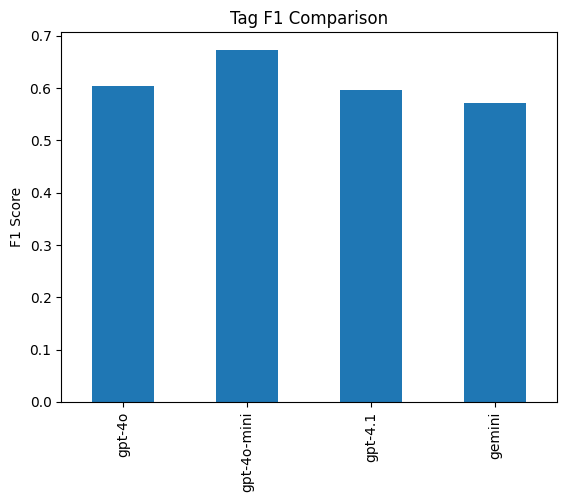

In [7]:
import matplotlib.pyplot as plt

df_results["tag_f1_avg"].plot(kind="bar", title="Tag F1 Comparison")
plt.ylabel("F1 Score")
plt.show()